# Assignment 1

- Tutorial: [Image Classification from Scratch](https://keras.io/examples/vision/image_classification_from_scratch/)


# Load and Visualize CIFAR-10


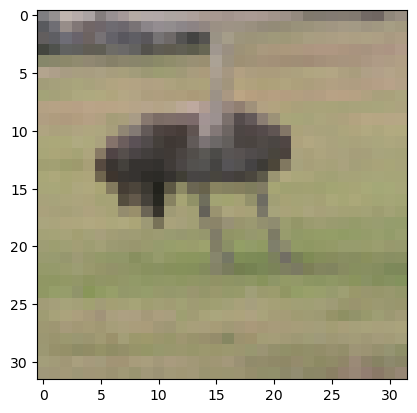

In [12]:
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras import layers, Input, Model, Sequential
from tensorflow.data import Dataset, AUTOTUNE


training_set, val_set = cifar10.load_data()

image = training_set[0][42]
plt.imshow(image)

# Data Preparation

- Option 2 from tutorial, training will be on CPU
- Data augmentation


In [13]:
factor = 0.1
zoom_factor = (-factor, factor)

augmentation_layers = Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor),
        layers.RandomZoom(height_factor=zoom_factor, width_factor=zoom_factor),
        layers.RandomTranslation(height_factor=factor, width_factor=factor),
    ]
)


def AugmentDataset(image, label):
    return augmentation_layers(image, training=True), label


batch_size = 64


def PrepareDataset(training_set: tuple, batch_size: int = batch_size):
    dataset = Dataset.from_tensor_slices(training_set)
    dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(AugmentDataset, num_parallel_calls=AUTOTUNE)
    dataset = dataset.prefetch(buffer_size=AUTOTUNE)
    return dataset


training_set = PrepareDataset(training_set=training_set)
val_set = Dataset.from_tensor_slices(val_set).batch(batch_size).prefetch(AUTOTUNE)

# Model Building

- VGG architecture, 3 convolution blocks
- Each block: (Convolution + Batch Normalization + Activation) \* 2 + Max Pooling(size 2, stride 2) + Dropout


In [14]:
def BlockGenerator(filters: int, dropout_rate: float, input):
    input = layers.Conv2D(filters=filters, kernel_size=(3, 3), padding="same")(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)

    input = layers.Conv2D(filters=filters, kernel_size=(3, 3), padding="same")(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)

    input = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))(input)
    result = layers.Dropout(rate=dropout_rate)(input)

    return result


def ClassifierBlockGenerator(class_number: int, nodes: int, dropout_rate: float, input):
    input = layers.GlobalAveragePooling2D()(input)
    input = layers.Dense(units=nodes)(input)
    input = layers.BatchNormalization()(input)
    input = layers.Activation("relu")(input)
    input = layers.Dropout(rate=dropout_rate)(input)
    result = layers.Dense(units=class_number, activation="softmax")(input)

    return result

In [ ]:
image_shape = (32, 32, 3)
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

input_block = Input(shape=image_shape)

rescaling_block = layers.Rescaling(scale=1 / 255)(input_block)

block_1 = BlockGenerator(filters=128, dropout_rate=0.2, input=rescaling_block)
block_2 = BlockGenerator(filters=256, dropout_rate=0.3, input=block_1)
block_3 = BlockGenerator(filters=512, dropout_rate=0.4, input=block_2)

output_block = ClassifierBlockGenerator(
    class_number=len(classes), nodes=256, dropout_rate=0.5, input=block_3
)

model = Model(inputs=input_block, outputs=output_block, name="Assignment_1")
model.summary()

Model: "Assignment_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,651,018 (17.74 MB)

 Trainable params: 4,647,178 (17.73 MB)

 Non-trainable params: 3,840 (15.00 KB)

# Model Optimization

- Adam
- Learning rate decay


In [ ]:
from keras import optimizers, losses, metrics, callbacks


cosineDecay = optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001, decay_steps=50 * 782
)
optimizer = optimizers.Adam(learning_rate=cosineDecay)

model.compile(
    optimizer=optimizer,
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callback_list = [
    # callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1, min_lr=1e-6),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=20, verbose=1, restore_best_weights=True
    ),
    callbacks.ModelCheckpoint("checkpoints/at_{epoch}.keras"),
]

# Training


In [29]:
history = model.fit(
    training_set, validation_data=val_set, epochs=50, callbacks=callback_list, verbose=1
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 715s 909ms/step - accuracy: 0.3885 - loss: 1.7060 - val_accuracy: 0.4572 - val_loss: 1.5641
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 752s 962ms/step - accuracy: 0.5338 - loss: 1.3056 - val_accuracy: 0.3820 - val_loss: 2.3768
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 730s 933ms/step - accuracy: 0.5973 - loss: 1.1480 - val_accuracy: 0.4685 - val_loss: 1.6993
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 725s 927ms/step - accuracy: 0.6428 - loss: 1.0366 - val_accuracy: 0.6192 - val_loss: 1.1903
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 732s 936ms/step - accuracy: 0.6765 - loss: 0.9433 - val_accuracy: 0.6700 - val_loss: 0.9919
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 758s 969ms/step - accuracy: 0.6993 - loss: 0.8756 - val_accuracy: 0.6030 - val_loss: 1.4293
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 768s 982ms/step - accuracy: 0.7236 - loss: 0.8190 - val_accuracy: 0.6863 - val_loss: 0.9742
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 780s 997ms/step - accuracy: 0.7369 -

KeyboardInterrupt: 

In [30]:
from keras import models

model_2 = models.load_model("checkpoints/at_11.keras")

history_2 = model_2.fit(
    training_set,
    validation_data=val_set,
    epochs=50,
    initial_epoch=11,
    callbacks=callback_list,
    verbose=1,
)

Epoch 12/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 1483s 2s/step - accuracy: 0.7900 - loss: 0.6207 - val_accuracy: 0.7664 - val_loss: 0.7090
Epoch 13/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 1686s 2s/step - accuracy: 0.7966 - loss: 0.6017 - val_accuracy: 0.7720 - val_loss: 0.6963
Epoch 14/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 1680s 2s/step - accuracy: 0.8072 - loss: 0.5699 - val_accuracy: 0.7827 - val_loss: 0.7142
Epoch 15/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 1407s 2s/step - accuracy: 0.8155 - loss: 0.5458 - val_accuracy: 0.7727 - val_loss: 0.7149
Epoch 16/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 783s 1s/step - accuracy: 0.8200 - loss: 0.5297 - val_accuracy: 0.8225 - val_loss: 0.5198
Epoch 17/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 707s 904ms/step - accuracy: 0.8261 - loss: 0.5098 - val_accuracy: 0.8089 - val_loss: 0.5767
Epoch 18/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 694s 888ms/step - accuracy: 0.8351 - loss: 0.4884 - val_accuracy: 0.7730 - val_loss: 0.7500
Epoch 19/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 686s 878ms/step - accuracy: 0.8420 - lo

# Plotting Accuracy


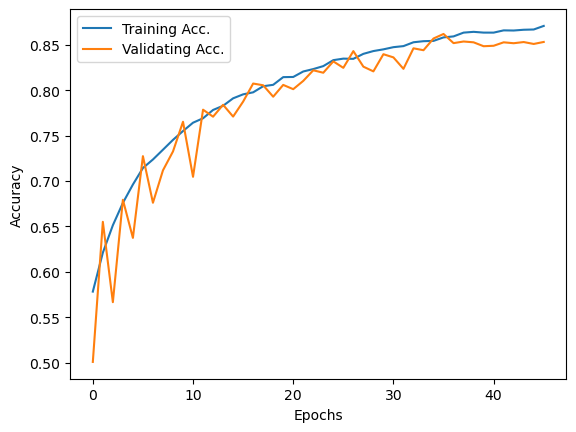

In [33]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

plt.plot(accuracy, label="Training Acc.")
plt.plot(val_accuracy, label="Validating Acc.")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()